In [99]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchview
import torchvision
from iohub import open_ome_zarr
from lightning.pytorch import seed_everything
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
from skimage import metrics
import sys

In [100]:
import pandas as pd
import seaborn as sns

In [101]:
# Read OME ZARR image dataset
def readImg(filename):
    dataset = open_ome_zarr(filename)
    return dataset

In [102]:
# Get field of view
def get_fov(dataset, fov):
    return dataset[f"0/{fov}/0/0"].numpy()

In [103]:
# Get z slice
def get_z_slice(image, z_slice):
    return image[z_slice]

In [104]:
# Calculate basic image statistics from intensity distributions
def get_stats(dist_array):
    mean = np.mean(dist_array)                      # mean
    median = np.median(dist_array)                  # median
    stdev = np.std(dist_array)                      # standard deviation
    q75, q25 = np.percentile(dist_array, (75, 25))  # 75th and 25th quartiles
    iqr = q75 - q25                                 # Inter-quartile range

    return (mean, median, iqr, stdev)

In [105]:
# Get statistics data
def get_dataframe(dataset):
    num_fov = len(dataset["0"])
    
    # FOV stats
    image_fov_stat = {
        'fov': [],
        'mean': [],
        'median': [],
        'iqr': [],
        'std': []
        }
    
    # Z slice stats
    image_zslice_stat = {
        'fov': [],
        'zslice': [],
        'mean': [],
        'median': [],
        'iqr': [],
        'std': []
        }
    
    # Calculate stt for each FOV and every z slice in FOVs
    for fov in range(num_fov):
        image = get_fov(dataset, fov).squeeze()
        num_z = image.shape[0]
        fov_stats = get_stats(image)

        image_fov_stat["fov"].append(fov)
        image_fov_stat["mean"].append(fov_stats[0])
        image_fov_stat["median"].append(fov_stats[1])
        image_fov_stat["iqr"].append(fov_stats[2])
        image_fov_stat["std"].append(fov_stats[3])
        
        print(f"Current FOV: {fov}")
        
        for z_slice in range(num_z):
            image_z_slice = get_z_slice(image, z_slice)
            zslice_stats = get_stats(image_z_slice)

            image_zslice_stat["fov"].append(fov)
            image_zslice_stat["zslice"].append(z_slice)
            image_zslice_stat["mean"].append(zslice_stats[0])
            image_zslice_stat["median"].append(zslice_stats[1])
            image_zslice_stat["iqr"].append(zslice_stats[2])
            image_zslice_stat["std"].append(zslice_stats[3])

    return pd.DataFrame(image_fov_stat), pd.DataFrame(image_zslice_stat)

In [129]:
def plot_dataDist(data, name):
    fig = plt.figure(figsize=(20,7.5))
    ax = sns.violinplot(
        data = data,
        x = data["fov"],
        y = data["std"] * 1e3,
        inner = 'quart'
    )
    ax.set_xlabel("Field Of View", size=15)
    ax.set_ylabel("Standard Deviation [x1e3]", size=15)
    ax.set_title(f"{name}", size = 20)
    sns.despine()
    plt.show()

In [130]:
filename = "/home/ankitr/MBL-Project/data/0-raw_data/1-H2B_dataset/input_phase/registered_output.zarr"
dataset = readImg(filename)
image_fov_stat, image_zslice_stat = get_dataframe(dataset)

Current FOV: 0


KeyboardInterrupt: 

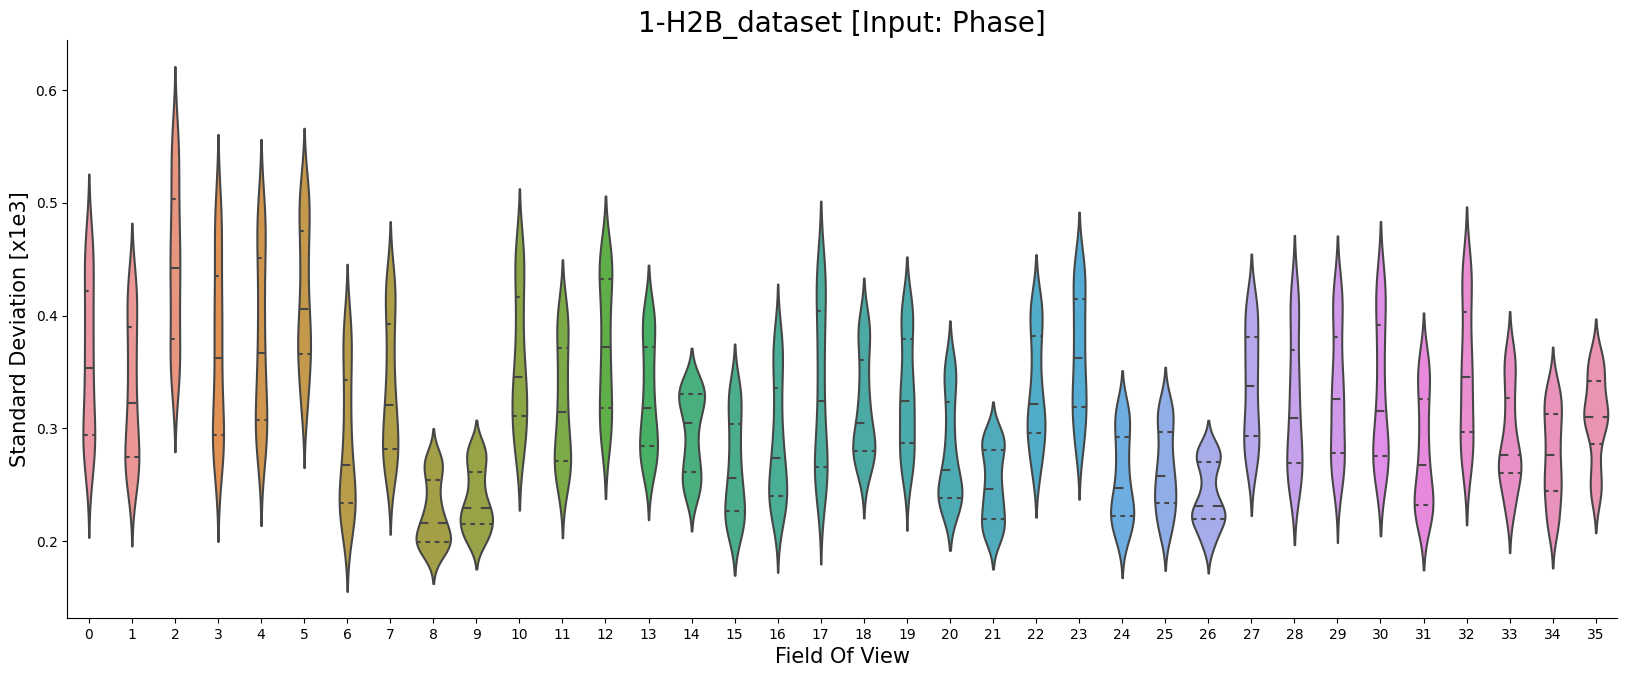

: 

In [131]:
plot_dataDist(image_zslice_stat, "1-H2B_dataset [Input: Phase]")